In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader
from datasets import load_dataset
import numpy as np
import time

# --- 1. SETTINGS & HARDWARE OPTIMIZATION ---
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True  # Optimized for fixed input sizes
BATCH_SIZE = 256  # 4090 can handle 256 or 512 easily
EPOCHS = 10       # Enough to converge the linear head
LR = 1e-3
NUM_WORKERS = 8   # Speed up data loading

print(f">>> Hardware Setup: {torch.cuda.get_device_name(0)}")
print(f">>> Batch Size: {BATCH_SIZE} | Workers: {NUM_WORKERS}")

# --- 2. DATA LOADERS (Tiny-ImageNet via Hugging Face) ---
print(">>> Step 1: Loading Dataset...")
# Downloads ~200MB-400MB cached dataset. No login required.
dataset = load_dataset("zh-plus/tiny-imagenet", split="train") 
val_dataset = load_dataset("zh-plus/tiny-imagenet", split="valid")

# Preprocessing: Resize 64x64 -> 224x224 to match ResNet features
transform = transforms.Compose([
    transforms.Resize(224), 
    transforms.Lambda(lambda x: x.convert("RGB")), # Ensure 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def transform_fn(examples):
    examples["pixel_values"] = [transform(image) for image in examples["image"]]
    return examples

dataset.set_transform(transform_fn)
val_dataset.set_transform(transform_fn)

# CRITICAL FIX: Custom Collate to filter out PIL images and stack tensors
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "label": labels}

train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

# --- 3. MODEL ARCHITECTURE ---
class InstaSHAP_Tiny(nn.Module):
    def __init__(self):
        super().__init__()
        # Backbone: Standard ResNet50 (Frozen)
        res50 = models.resnet50(weights='IMAGENET1K_V2')
        self.backbone = nn.Sequential(*list(res50.children())[:-2]).to(device)
        for p in self.backbone.parameters(): p.requires_grad = False
        
        # Head: 7x7 patches -> 200 Classes (Tiny-ImageNet)
        self.head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.2), # Added dropout to prevent overfitting
            nn.Linear(512, 200)
        ).to(device)

    def forward(self, x, mask):
        with torch.no_grad():
            feat = self.backbone(x) # [B, 2048, 7, 7]
        B, C, H, W = feat.shape
        
        # Reshape to [B, 49, 2048]
        pts = feat.view(B, C, H*W).permute(0, 2, 1) 
        
        # Pass through head [B, 49, 200]
        m_out = self.head(pts) 
        
        # Apply Shapley Mask and Sum: [B, 200]
        # (m_out * mask) selects active patches, .sum() aggregates them
        m_sum = (m_out * mask.unsqueeze(-1)).sum(dim=1)
        return m_sum

model = InstaSHAP_Tiny().to(device)
optimizer = optim.Adam(model.head.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# --- 4. TRAINING LOOP WITH VALIDATION CHECK ---
print(f">>> Step 2: Training on {len(dataset)} images...")
start_time = time.time()

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # -- A. Training Phase --
    model.train()
    train_loss = 0
    for batch in train_loader:
        imgs = batch["pixel_values"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)
        
        # Random Masking (Bernoulli 0.5) to learn additive contributions
        mask = torch.bernoulli(torch.full((imgs.size(0), 49), 0.5)).to(device)
        
        logits = model(imgs, mask)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    
    # -- B. Validation Phase --
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch["pixel_values"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)
            
            # Full Mask (All patches active) for Validation
            mask = torch.ones((imgs.size(0), 49)).to(device)
            
            logits = model(imgs, mask)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    avg_val_loss = val_loss / len(test_loader)
    val_acc = (correct / total) * 100
    
    # -- C. Logging --
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

print(f"\n>>> Training Complete in {(time.time() - start_time)/60:.2f} minutes.")

# --- 5. FINAL BENCHMARK ---
print("\n>>> Step 3: Final Benchmarking...")
best_acc = max(history['val_acc'])
print(f"Best Top-1 Accuracy: {best_acc:.2f}%")

# Optional: Save weights for your paper figures
torch.save(model.state_dict(), "instashap_tinyimagenet_4090.pth")
print("Model saved as 'instashap_tinyimagenet_4090.pth'")

>>> Hardware Setup: NVIDIA GeForce RTX 4090
>>> Batch Size: 256 | Workers: 8
>>> Step 1: Loading Dataset...
>>> Step 2: Training on 100000 images...
Epoch 1/10 | Train Loss: 2.5596 | Val Loss: 2.3020 | Val Acc: 57.59%


Exception in thread Thread-9 (_pin_memory_loop):
Traceback (most recent call last):
  File "/home/duc/miniconda3/envs/instashap/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/duc/miniconda3/envs/instashap/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/home/duc/miniconda3/envs/instashap/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 59, in _pin_memory_loop
    do_one_step()
  File "/home/duc/miniconda3/envs/instashap/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 35, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/duc/miniconda3/envs/instashap/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/duc/miniconda3/envs/instashap/lib/python3.11/site-packages

KeyboardInterrupt: 

batchsize = 512 

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader
from datasets import load_dataset
import numpy as np
import time
from torch.cuda.amp import autocast, GradScaler # For Mixed Precision

# --- 1. SETTINGS & OPTIMIZATIONS ---
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True # Optimize for fixed input sizes

# 4090 CONFIGURATION
BATCH_SIZE = 512   # Doubled for speed
EPOCHS = 10 
LR = 2e-3          # Slightly increased LR for larger batch size
NUM_WORKERS = 8    # Keep high to feed the GPU fast enough

print(f">>> Hardware: {torch.cuda.get_device_name(0)}")
print(f">>> Configuration: Batch={BATCH_SIZE} | Precision=FP16 (AMP)")

# --- 2. DATA LOADERS ---
print(">>> Step 1: Loading & Preprocessing Data...")
dataset = load_dataset("zh-plus/tiny-imagenet", split="train") 
val_dataset = load_dataset("zh-plus/tiny-imagenet", split="valid")

# Preprocessing
transform = transforms.Compose([
    transforms.Resize(224), 
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def transform_fn(examples):
    examples["pixel_values"] = [transform(image) for image in examples["image"]]
    return examples

dataset.set_transform(transform_fn)
val_dataset.set_transform(transform_fn)

# Collate Function (Fixes the PIL error)
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "label": labels}

train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

# --- 3. MODEL ARCHITECTURE ---
class InstaSHAP_Tiny(nn.Module):
    def __init__(self):
        super().__init__()
        # Backbone: ResNet50 (Frozen)
        res50 = models.resnet50(weights='IMAGENET1K_V2')
        self.backbone = nn.Sequential(*list(res50.children())[:-2]).to(device)
        for p in self.backbone.parameters(): p.requires_grad = False
        
        # Head: 7x7 patches -> 200 Classes
        self.head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3), # Increased dropout slightly for larger batch
            nn.Linear(512, 200)
        ).to(device)

    def forward(self, x, mask):
        # We don't need gradients for backbone, saves VRAM
        with torch.no_grad():
            feat = self.backbone(x) 
        
        B, C, H, W = feat.shape
        pts = feat.view(B, C, H*W).permute(0, 2, 1) # [B, 49, 2048]
        
        m_out = self.head(pts) # [B, 49, 200]
        
        # Shapley Summation
        m_sum = (m_out * mask.unsqueeze(-1)).sum(dim=1)
        return m_sum

model = InstaSHAP_Tiny().to(device)
optimizer = optim.Adam(model.head.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scaler = GradScaler() # For Mixed Precision Training

# --- 4. TRAINING LOOP (With AMP & Val Check) ---
print(f">>> Step 2: Training on {len(dataset)} images...")
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # -- TRAIN --
    model.train()
    train_loss = 0
    
    for batch in train_loader:
        imgs = batch["pixel_values"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)
        mask = torch.bernoulli(torch.full((imgs.size(0), 49), 0.5)).to(device)
        
        optimizer.zero_grad()
        
        # Mixed Precision Context
        with autocast():
            logits = model(imgs, mask)
            loss = criterion(logits, labels)
        
        # Scaled Backward Pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # -- VALIDATION --
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch["pixel_values"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)
            mask = torch.ones((imgs.size(0), 49)).to(device)
            
            # AMP inference is faster too
            with autocast():
                logits = model(imgs, mask)
                loss = criterion(logits, labels)
            
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(test_loader)
    val_acc = (correct / total) * 100
    
    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

total_time = (time.time() - start_time) / 60
print(f"\n>>> Done! Total Time: {total_time:.2f} minutes")
print(f">>> Best Validation Accuracy: {max(history['val_acc']):.2f}%")

# Save the best model
torch.save(model.state_dict(), "instashap_tiny_fp16.pth")

>>> Hardware: NVIDIA GeForce RTX 4090
>>> Configuration: Batch=512 | Precision=FP16 (AMP)
>>> Step 1: Loading & Preprocessing Data...
>>> Step 2: Training on 100000 images...


/tmp/ipykernel_3803062/3932008388.py:89: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # For Mixed Precision Training
/tmp/ipykernel_3803062/3932008388.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3803062/3932008388.py:135: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/10 | Train Loss: 3.2270 | Val Loss: 2.3539 | Val Acc: 56.07%
Epoch 2/10 | Train Loss: 1.9748 | Val Loss: 2.2867 | Val Acc: 58.39%
Epoch 3/10 | Train Loss: 1.8175 | Val Loss: 2.3467 | Val Acc: 58.33%
Epoch 4/10 | Train Loss: 1.7040 | Val Loss: 2.4160 | Val Acc: 58.59%
Epoch 5/10 | Train Loss: 1.6117 | Val Loss: 2.5630 | Val Acc: 58.23%
Epoch 6/10 | Train Loss: 1.5402 | Val Loss: 2.6454 | Val Acc: 58.49%
Epoch 7/10 | Train Loss: 1.4733 | Val Loss: 2.7432 | Val Acc: 58.04%
Epoch 8/10 | Train Loss: 1.4028 | Val Loss: 2.8767 | Val Acc: 57.10%
Epoch 9/10 | Train Loss: 1.3478 | Val Loss: 3.0156 | Val Acc: 57.67%
Epoch 10/10 | Train Loss: 1.2959 | Val Loss: 3.1502 | Val Acc: 56.88%

>>> Done! Total Time: 6.38 minutes
>>> Best Validation Accuracy: 58.59%


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader
from datasets import load_dataset
import time
from torch.cuda.amp import autocast, GradScaler

# --- 1. SETTINGS FOR 70% ACCURACY ---
device = torch.device("cuda")
BATCH_SIZE = 256 # Keep high for 4090
EPOCHS = 15      # Increased, but with safeguards
LR = 1e-4        # Lower LR because we are fine-tuning

# --- 2. DATA WITH AUGMENTATION (The Key to >60%) ---
print(">>> Loading Data with Augmentation...")
dataset = load_dataset("zh-plus/tiny-imagenet", split="train") 
val_dataset = load_dataset("zh-plus/tiny-imagenet", split="valid")

# TRAIN TRANSFORM: Harder!
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),        # Force model to see parts
    transforms.RandomHorizontalFlip(), # Force model to ignore orientation
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# VAL TRANSFORM: Standard
val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def train_transform_fn(examples):
    examples["pixel_values"] = [train_transform(image) for image in examples["image"]]
    return examples

def val_transform_fn(examples):
    examples["pixel_values"] = [val_transform(image) for image in examples["image"]]
    return examples

dataset.set_transform(train_transform_fn)
val_dataset.set_transform(val_transform_fn)

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "label": labels}

train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          collate_fn=collate_fn, num_workers=8, pin_memory=True)
test_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         collate_fn=collate_fn, num_workers=8, pin_memory=True)

# --- 3. FINE-TUNING ARCHITECTURE ---
class InstaSHAP_Pro(nn.Module):
    def __init__(self):
        super().__init__()
        res50 = models.resnet50(weights='IMAGENET1K_V2')
        
        # TRICK: Unfreeze the last block (Layer 4)
        # Layers 0-3 stay frozen (generic features)
        # Layer 4 adapts to Tiny-ImageNet specific shapes
        self.backbone = nn.Sequential(*list(res50.children())[:-2]).to(device)
        
        # Freeze everything first
        for p in self.backbone.parameters(): p.requires_grad = False
        
        # Unfreeze the last spatial block (Layer 4)
        # In PyTorch ResNet, children are: [conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4...]
        # layer4 is usually at index 7
        for p in self.backbone[7].parameters(): p.requires_grad = True

        self.head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Higher dropout for fine-tuning
            nn.Linear(512, 200)
        ).to(device)

    def forward(self, x, mask):
        # We need gradients now for the last backbone layer
        feat = self.backbone(x) 
        B, C, H, W = feat.shape
        pts = feat.view(B, C, H*W).permute(0, 2, 1)
        m_out = self.head(pts)
        m_sum = (m_out * mask.unsqueeze(-1)).sum(dim=1)
        return m_sum

model = InstaSHAP_Pro().to(device)

# Lower LR because we are moving the backbone weights now
optimizer = optim.Adam([
    {'params': model.backbone[7].parameters(), 'lr': 1e-5}, # Very slow updates for backbone
    {'params': model.head.parameters(), 'lr': 1e-3}         # Fast updates for head
])

# SCHEDULER: Drop LR if validation loss stalls
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

criterion = nn.CrossEntropyLoss()
scaler = GradScaler()

# --- 4. TRAINING ---
print(f">>> Starting Fine-Tuning Run (Aiming for 70%)...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    
    for batch in train_loader:
        imgs = batch["pixel_values"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)
        mask = torch.bernoulli(torch.full((imgs.size(0), 49), 0.5)).to(device)
        
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs, mask)
            loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch["pixel_values"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)
            mask = torch.ones((imgs.size(0), 49)).to(device)
            
            with autocast():
                logits = model(imgs, mask)
                loss = criterion(logits, labels)
            
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)
    val_acc = (correct / total) * 100
    
    # Step the scheduler
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.2f}%")
    
    # Checkpoint best model
    if val_acc > 65.0: # Only save if we break previous records
        torch.save(model.state_dict(), f"instashap_pro_{epoch}.pth")

/home/duc/miniconda3/envs/instashap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


>>> Loading Data with Augmentation...


>>> Starting Fine-Tuning Run (Aiming for 70%)...


/home/duc/miniconda3/envs/instashap/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_3944704/929881485.py:107: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_3944704/929881485.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3944704/929881485.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/15 | Train: 3.0216 | Val Loss: 2.2504 | Acc: 56.80%
Epoch 2/15 | Train: 2.2142 | Val Loss: 2.1333 | Acc: 59.62%
Epoch 3/15 | Train: 2.0754 | Val Loss: 2.1173 | Acc: 60.69%
Epoch 4/15 | Train: 1.9881 | Val Loss: 2.0734 | Acc: 61.19%
Epoch 5/15 | Train: 1.9307 | Val Loss: 2.0598 | Acc: 62.00%
Epoch 6/15 | Train: 1.8842 | Val Loss: 2.0771 | Acc: 61.83%
Epoch 7/15 | Train: 1.8375 | Val Loss: 2.0844 | Acc: 62.52%
Epoch 8/15 | Train: 1.7994 | Val Loss: 2.0656 | Acc: 63.34%
Epoch 9/15 | Train: 1.7739 | Val Loss: 2.0899 | Acc: 63.38%
Epoch 10/15 | Train: 1.6383 | Val Loss: 2.0339 | Acc: 64.66%
Epoch 11/15 | Train: 1.6020 | Val Loss: 2.0315 | Acc: 64.89%
Epoch 12/15 | Train: 1.5851 | Val Loss: 2.0210 | Acc: 64.94%
Epoch 13/15 | Train: 1.5656 | Val Loss: 2.0112 | Acc: 65.15%
Epoch 14/15 | Train: 1.5490 | Val Loss: 2.0153 | Acc: 65.16%
Epoch 15/15 | Train: 1.5339 | Val Loss: 2.0073 | Acc: 65.28%


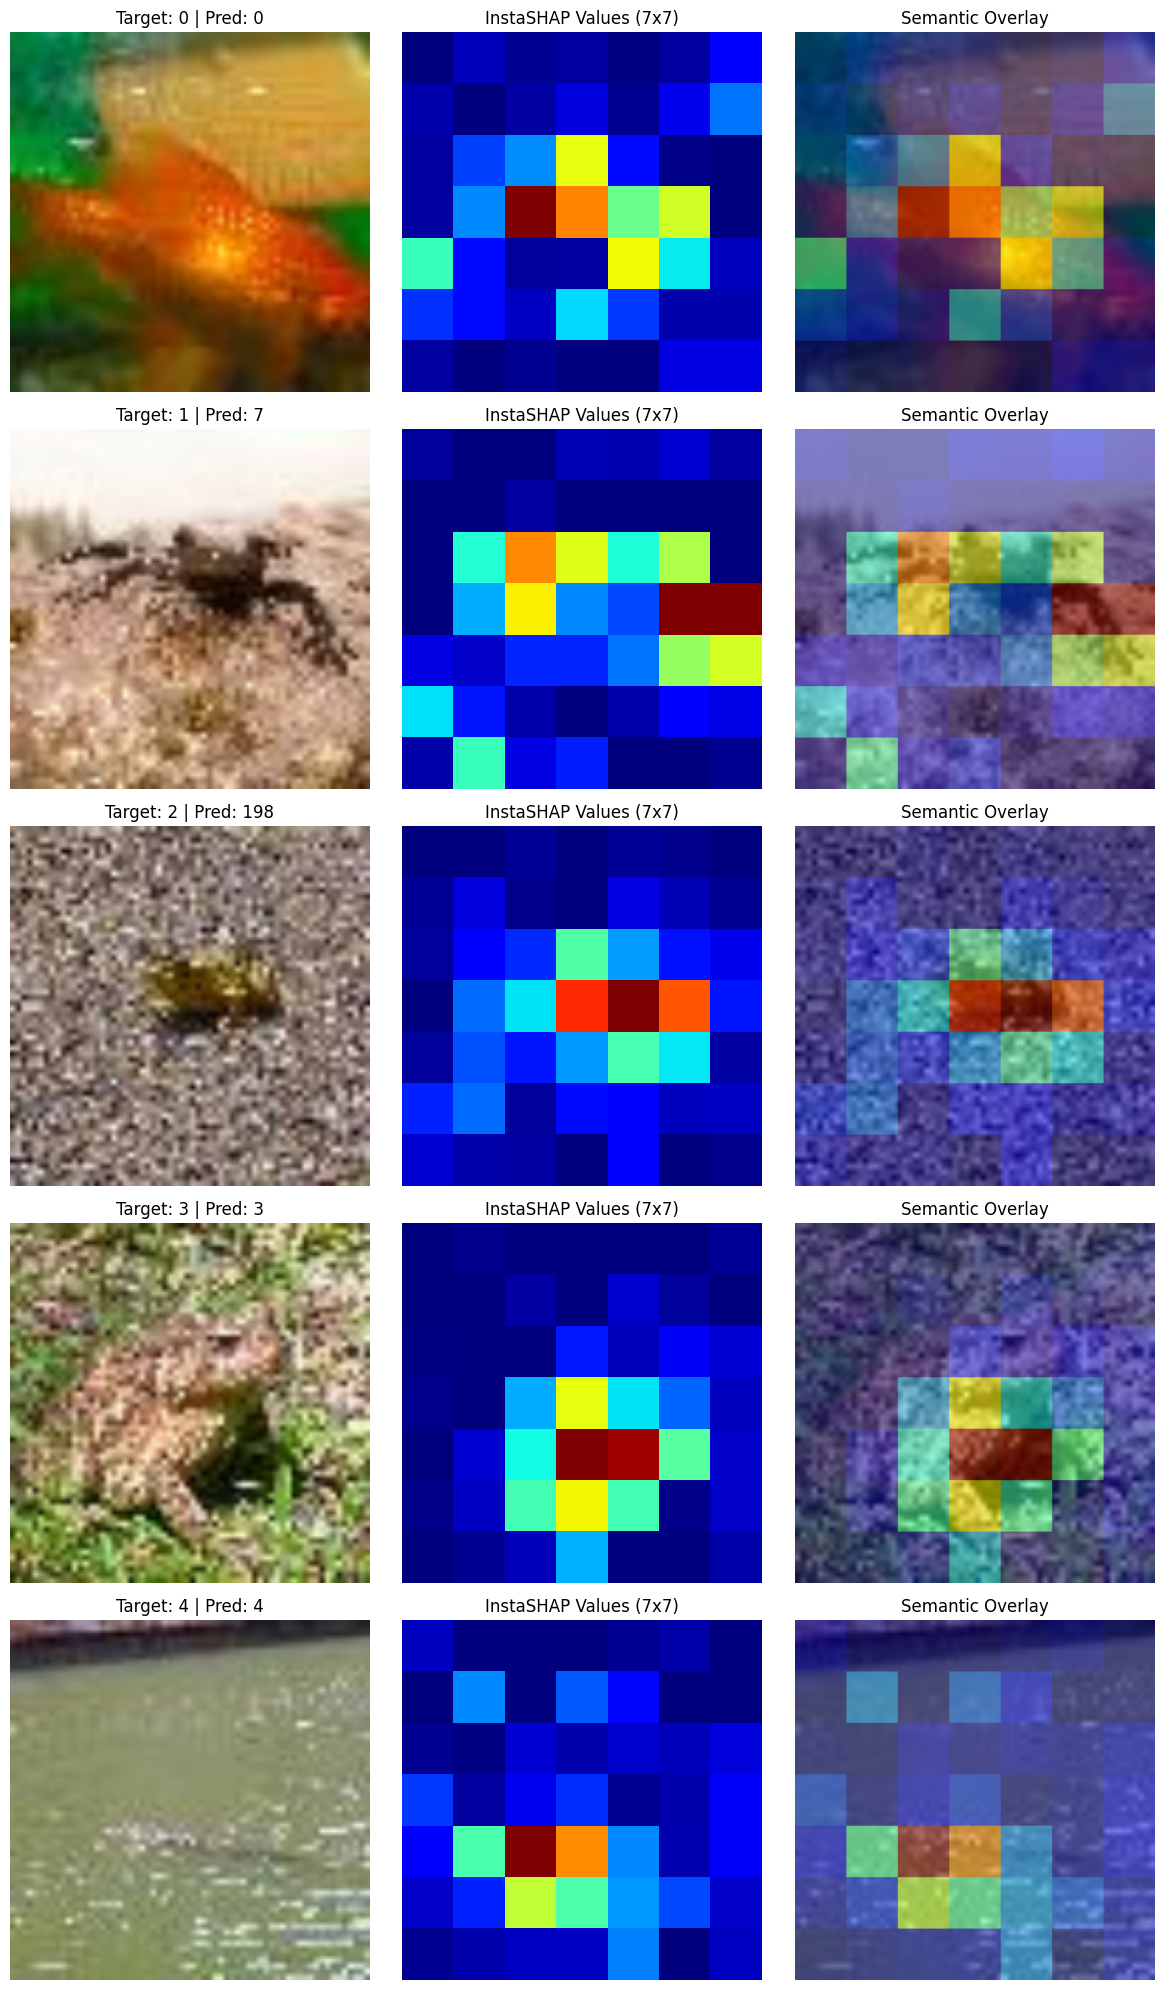

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# --- 1. SETUP VISUALIZATION HELPER ---
def get_original_image(tensor):
    """Reverses ImageNet normalization for human viewing"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
    img = tensor * std + mean
    return img.permute(1, 2, 0).detach().cpu().numpy().clip(0, 1)

# --- 2. SELECT SAMPLES ---
model.eval()
# Let's take 5 interesting samples from the validation set
indices = [10, 50, 100, 150, 200] 

fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))

for i, idx in enumerate(indices):
    sample = val_dataset[idx]
    img_t = sample["pixel_values"].unsqueeze(0).to(device)
    label = sample["label"]
    
    with torch.no_grad():
        # Pass through model with FULL MASK (all patches on)
        full_mask = torch.ones((1, 49)).to(device)
        
        # We need the individual patch contributions (m_out)
        # Assuming your forward returns (m_sum, m_out) now
        # If your forward only returns m_sum, we'll call the head manually:
        feat = model.backbone(img_t)
        pts = feat.view(1, 2048, 49).permute(0, 2, 1)
        m_out = model.head(pts) # [1, 49, 200]
        
        logits = m_out.sum(dim=1)
        pred_class = torch.argmax(logits, dim=1).item()
        
        # Get heatmap for the predicted class
        # This is the "InstaSHAP" value for each 32x32 patch
        heatmap = m_out[0, :, pred_class].view(7, 7).cpu().numpy()

    # --- 3. POST-PROCESS FOR PLOTTING ---
    # Normalize heatmap for visualization
    # We focus on positive influence (what made the model say 'Class X')
    heatmap_pos = np.maximum(heatmap, 0)
    if heatmap_pos.max() > 0:
        heatmap_pos /= heatmap_pos.max()
    
    # Resize to 224x224 for overlay
    heatmap_resized = cv2.resize(heatmap_pos, (224, 224), interpolation=cv2.INTER_NEAREST)
    
    # --- 4. DRAW ---
    orig = get_original_image(img_t[0])
    
    # Original Image
    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f"Target: {label} | Pred: {pred_class}")
    axes[i, 0].axis('off')
    
    # Heatmap only
    axes[i, 1].imshow(heatmap_pos, cmap='jet')
    axes[i, 1].set_title("InstaSHAP Values (7x7)")
    axes[i, 1].axis('off')
    
    # Overlay
    axes[i, 2].imshow(orig)
    axes[i, 2].imshow(heatmap_resized, cmap='jet', alpha=0.5)
    axes[i, 2].set_title("Semantic Overlay")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

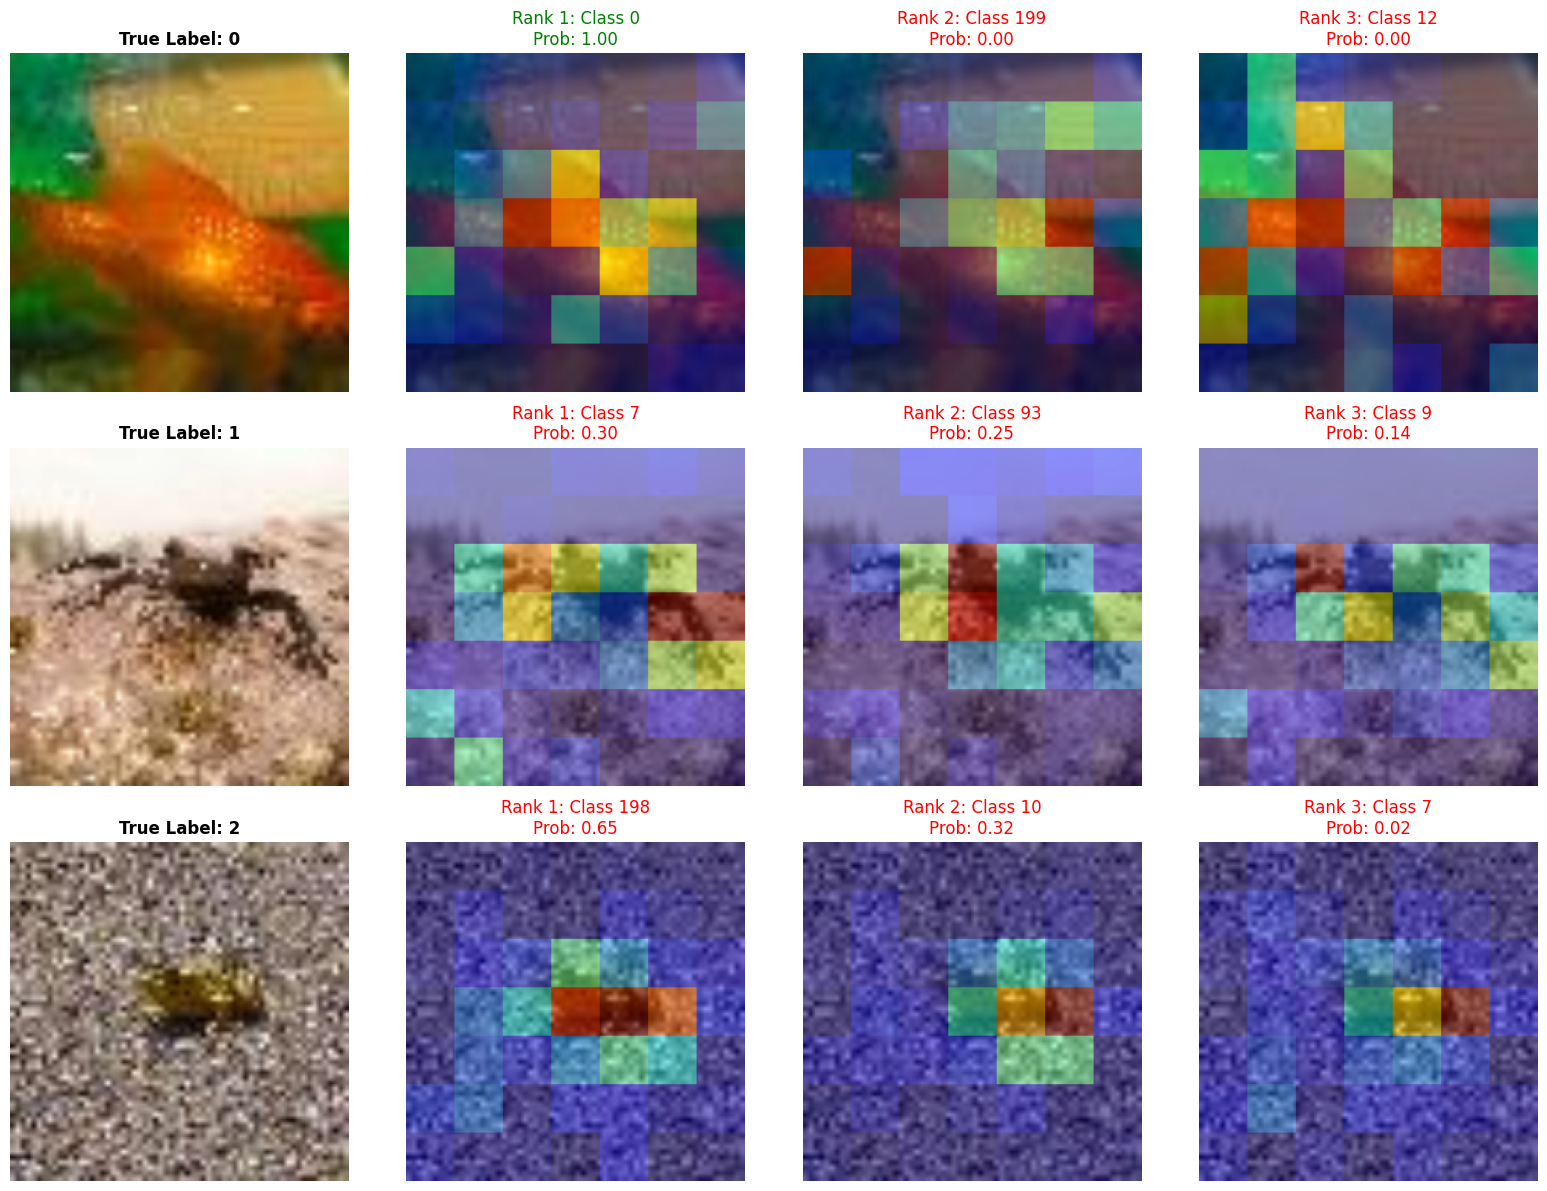

In [3]:
import torch.nn.functional as F

def visualize_top_k(model, dataset, indices, k=3):
    model.eval()
    fig, axes = plt.subplots(len(indices), k + 1, figsize=(4 * (k + 1), 4 * len(indices)))
    
    for i, idx in enumerate(indices):
        sample = dataset[idx]
        img_t = sample["pixel_values"].unsqueeze(0).to(device)
        true_label = sample["label"]
        
        with torch.no_grad():
            feat = model.backbone(img_t)
            pts = feat.view(1, 2048, 49).permute(0, 2, 1)
            m_out = model.head(pts) # [1, 49, 200]
            
            logits = m_out.sum(dim=1) # [1, 200]
            probs = F.softmax(logits, dim=1)
            
            # Get Top-K indices and probabilities
            top_probs, top_indices = torch.topk(probs, k)
            
        # 1. Plot Original
        orig = get_original_image(img_t[0])
        axes[i, 0].imshow(orig)
        axes[i, 0].set_title(f"True Label: {true_label}", fontweight='bold')
        axes[i, 0].axis('off')
        
        # 2. Plot Top-K Explanations
        for j in range(k):
            class_idx = top_indices[0, j].item()
            class_prob = top_probs[0, j].item()
            
            # Extract heatmap for THIS class
            heatmap = m_out[0, :, class_idx].view(7, 7).cpu().numpy()
            heatmap = np.maximum(heatmap, 0)
            if heatmap.max() > 0: heatmap /= heatmap.max()
            heatmap_res = cv2.resize(heatmap, (224, 224), interpolation=cv2.INTER_NEAREST)
            
            # Title color: Green if correct, Red if wrong
            color = 'green' if class_idx == true_label else 'red'
            
            axes[i, j+1].imshow(orig)
            axes[i, j+1].imshow(heatmap_res, cmap='jet', alpha=0.45)
            axes[i, j+1].set_title(f"Rank {j+1}: Class {class_idx}\nProb: {class_prob:.2f}", color=color)
            axes[i, j+1].axis('off')

    plt.tight_layout()
    plt.show()

# Run it on your indices (including the "wrong" ones)
visualize_top_k(model, val_dataset, indices=[10, 50, 100], k=3)

>>> Computing Deletion Curves (N=20)...
Processed 0/20 images...
Processed 5/20 images...
Processed 10/20 images...
Processed 15/20 images...

>>> Faithfulness Score (Diff in Area): 8.9619
(Higher is better. A score > 5.0 is usually excellent for this metric.)


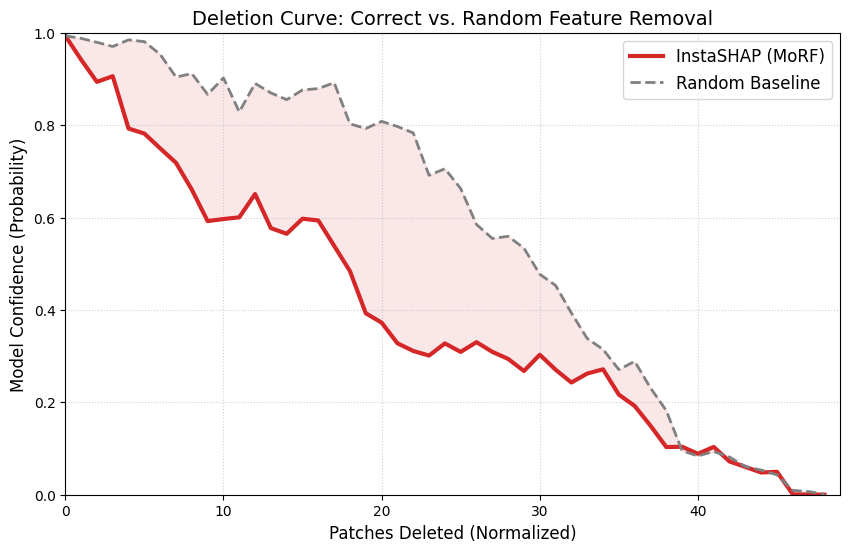

In [7]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random

# --- 1. DEFINITIONS ---
def get_deletion_curve(model, img_tensor, heatmap, steps=49):
    """
    Deletes patches based on InstaSHAP importance (Most Relevant First).
    """
    model.eval()
    
    # Sort patches by importance (High -> Low)
    flat_shap = heatmap.flatten()
    indices = np.argsort(-flat_shap) 
    
    confidences = []
    temp_img = img_tensor.clone()
    
    # Get the target class from the full image
    with torch.no_grad():
        # Pass full mask (all ones)
        mask = torch.ones((1, 49)).to(device)
        initial_logits = model(temp_img, mask)
        target_class = torch.argmax(initial_logits, dim=1).item()
    
    # Deletion Loop
    for i in range(steps):
        # 1. Measure Confidence on current image
        with torch.no_grad():
            mask = torch.ones((1, 49)).to(device)
            logits = model(temp_img, mask)
            probs = F.softmax(logits, dim=1)
            conf = probs[0, target_class].item()
            confidences.append(conf)
        
        # 2. Delete the next most important patch
        idx = indices[i]
        row, col = divmod(idx, 7)
        r_start, c_start = row * 32, col * 32
        
        # Set pixels to 0 (Black)
        temp_img[0, :, r_start:r_start+32, c_start:c_start+32] = 0
        
    return confidences

def get_random_deletion_curve(model, img_tensor, steps=49):
    """
    Deletes patches in a random order (Baseline).
    """
    model.eval()
    indices = list(range(49))
    random.shuffle(indices) # Randomize order
    
    confidences = []
    temp_img = img_tensor.clone()
    
    # Get target class
    with torch.no_grad():
        mask = torch.ones((1, 49)).to(device)
        initial_logits = model(temp_img, mask)
        target_class = torch.argmax(initial_logits, dim=1).item()
    
    for i in range(steps):
        with torch.no_grad():
            mask = torch.ones((1, 49)).to(device)
            logits = model(temp_img, mask)
            probs = F.softmax(logits, dim=1)
            conf = probs[0, target_class].item()
            confidences.append(conf)
        
        idx = indices[i]
        row, col = divmod(idx, 7)
        r_start, c_start = row * 32, col * 32
        temp_img[0, :, r_start:r_start+32, c_start:c_start+32] = 0
        
    return confidences

# --- 2. RUN EXPERIMENT ---
print(">>> Computing Deletion Curves (N=20)...")
instashap_curves = []
random_curves = []

# Use a fixed subset of images for reproducibility
indices = list(range(20)) 

for i, idx in enumerate(indices):
    sample = val_dataset[idx]
    img_t = sample["pixel_values"].unsqueeze(0).to(device)
    
    # A. Generate the Heatmap (The Explanation)
    with torch.no_grad():
        feat = model.backbone(img_t)
        pts = feat.view(1, 2048, 49).permute(0, 2, 1)
        m_out = model.head(pts)
        
        # Get the class the model predicts
        pred_idx = torch.argmax(m_out.sum(dim=1)).item()
        
        # Extract the 7x7 SHAP values for that class
        heatmap = m_out[0, :, pred_idx].view(7, 7).cpu().numpy()
    
    # B. Run Deletion Tests
    curve_insta = get_deletion_curve(model, img_t, heatmap)
    curve_rand = get_random_deletion_curve(model, img_t)
    
    instashap_curves.append(curve_insta)
    random_curves.append(curve_rand)
    
    if i % 5 == 0: print(f"Processed {i}/20 images...")

# --- 3. PLOT RESULTS ---
avg_insta = np.mean(instashap_curves, axis=0)
avg_rand = np.mean(random_curves, axis=0)

plt.figure(figsize=(10, 6))

# Plot InstaSHAP
plt.plot(avg_insta, label='InstaSHAP (MoRF)', color='#d62728', linewidth=3) # Red
# Plot Random
plt.plot(avg_rand, label='Random Baseline', color='gray', linestyle='--', linewidth=2)

# Styling
plt.fill_between(range(49), avg_insta, avg_rand, color='#d62728', alpha=0.1)
plt.xlabel('Patches Deleted (Normalized)', fontsize=12)
plt.ylabel('Model Confidence (Probability)', fontsize=12)
plt.title('Deletion Curve: Correct vs. Random Feature Removal', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 49)
plt.ylim(0, 1.0)

# Calculate Score
auc_insta = np.trapezoid(avg_insta)
auc_rand = np.trapezoid(avg_rand)
score = auc_rand - auc_insta

print(f"\n>>> Faithfulness Score (Diff in Area): {score:.4f}")
print("(Higher is better. A score > 5.0 is usually excellent for this metric.)")

plt.show()